Butterworth bandpass filter to isolate each band seems widely used by reasearch teams compared to Fourier decomposition and faster method so I used Butterworth bandpass filter.

Burttherworth avoids ringing, and produces equivalent band-limited signals for downstream PCA.

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir('/content/drive/My Drive/Group 10 Project/data/eegmmidb/')[:5])

DATA_PATH = "/content/drive/My Drive/Group 10 Project/data/eegmmidb/"

Mounted at /content/drive
['64_channel_sharbrough-old.png', 'SHA256SUMS.txt', 'ANNOTATORS', 'RECORDS', '64_channel_sharbrough.pdf']


In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
processed_dir = '/content/drive/My Drive/Group 10 Project/data/processed_subject_epochs'
subjects = sorted(os.listdir(processed_dir))
print(f"Found {len(subjects)} subject folders.")
print("First few:", subjects[:5])
print(f"\nContents of {subjects[0]}:", os.listdir(os.path.join(processed_dir, subjects[0])))

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import welch

# Dataset constants
FS = 160  # PhysioNet EEG sampling rate (Hz)
K = 27    # Number of PCA components (matches Person 2)
CONDITIONS = ["left_fist", "right_fist", "both_fists", "both_feet", "rest"]

# Frequency bands (Hz) — gamma dropped because data is low-pass filtered
BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}

Mounted at /content/drive
Found 110 subject folders.
First few: ['S001', 'S002', 'S003', 'S004', 'S005']

Contents of S001: ['epochs.npz', 'metadata.csv']


Use below code for loading the data.

In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import gc

base_dir = Path("/content/drive/My Drive/Group 10 Project/data/processed_subject_epochs")
bad_subjects = {"S088", "S092", "S100"}

# --- MEMORY KNOB: start small, scale up later ---
MAX_SUBJECTS = 30   # try 30 first; if stable, increase to 50, 70, all
USE_FLOAT32  = True # halves memory vs float64

subject_dirs = sorted([
    d for d in base_dir.iterdir()
    if d.is_dir() and d.name.startswith("S")
])
print(f"Subjects detected: {len(subject_dirs)}")

condition_data = defaultdict(list)
kept_subjects = []
skipped = []

for subj_dir in subject_dirs:
    if subj_dir.name in bad_subjects:
        skipped.append(subj_dir.name)
        continue
    if len(kept_subjects) >= MAX_SUBJECTS:
        break

    npz_path = subj_dir / "epochs.npz"
    if not npz_path.exists():
        continue

    with np.load(npz_path) as subj_npz:
        for cond in subj_npz.files:
            arr = subj_npz[cond]
            if USE_FLOAT32:
                arr = arr.astype(np.float32)
            condition_data[cond].append(arr)

    kept_subjects.append(subj_dir.name)

print(f"Subjects kept: {len(kept_subjects)}")
print(f"Bad subjects skipped: {skipped}")

# Concatenate
condition_arrays = {}
for cond, arrays in condition_data.items():
    condition_arrays[cond] = np.concatenate(arrays, axis=0)
    # Free the per-subject list right away
    condition_data[cond] = None
gc.collect()

print("\nCondition dataset shapes:")
for cond in sorted(condition_arrays.keys()):
    print(f"  {cond}: {condition_arrays[cond].shape}  ({condition_arrays[cond].nbytes/1e6:.0f} MB)")

Subjects detected: 109
Subjects kept: 30
Bad subjects skipped: []

Condition dataset shapes:
  both_feet: (1354, 64, 401)  (139 MB)
  both_fists: (1346, 64, 401)  (138 MB)
  left_fist: (1365, 64, 401)  (140 MB)
  rest: (5040, 64, 401)  (517 MB)
  right_fist: (1335, 64, 401)  (137 MB)


Define the bandpass filter:

In [3]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

FS = 160  # PhysioNet sampling rate in Hz

def bandpass_epochs(epochs, low_hz, high_hz, fs=FS, order=4):
    """Filter EEG epochs to a specific frequency band.

    epochs: array of shape (n_epochs, n_channels, n_times)
    Returns array of the same shape.
    """
    b, a = signal.butter(order, [low_hz, high_hz], btype='band', fs=fs)
    return signal.filtfilt(b, a, epochs, axis=-1)

Test the function with synthetic data:

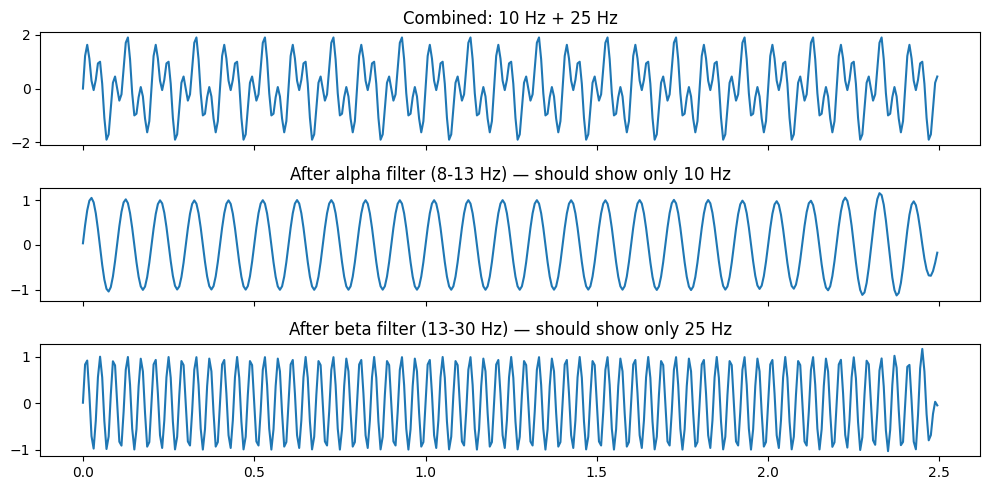

In [5]:
# Make a 2.5-second signal = 400 samples at 160 Hz
# Sum of 10 Hz (alpha) + 25 Hz (beta) sine waves
t = np.arange(400) / FS
fake = np.sin(2*np.pi*10*t) + np.sin(2*np.pi*25*t)
fake_epochs = fake.reshape(1, 1, -1)  # match EEG shape

alpha_only = bandpass_epochs(fake_epochs, 8, 13)
beta_only = bandpass_epochs(fake_epochs, 13, 30)

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, fake); axes[0].set_title("Combined: 10 Hz + 25 Hz")
axes[1].plot(t, alpha_only[0, 0]); axes[1].set_title("After alpha filter (8-13 Hz) — should show only 10 Hz")
axes[2].plot(t, beta_only[0, 0]); axes[2].set_title("After beta filter (13-30 Hz) — should show only 25 Hz")
plt.tight_layout(); plt.show()

Before running the full PCA, use small portion of data to test:

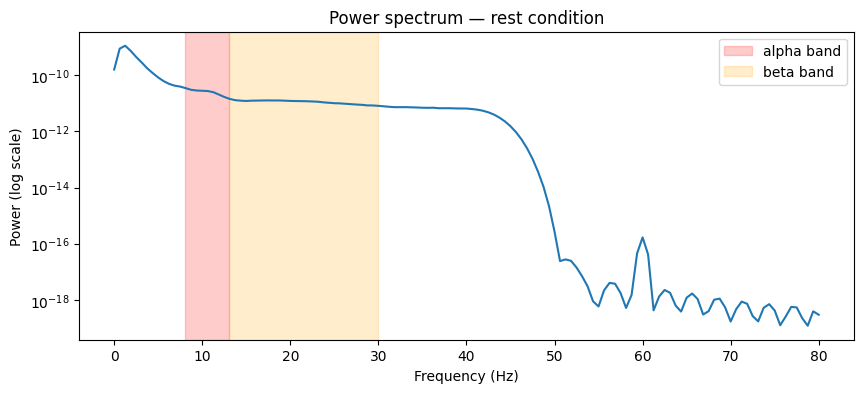

In [4]:
from scipy.signal import welch

# Pick one condition, average across epochs and channels to get a mean spectrum
example = condition_arrays["rest"]  # (n_epochs, 64, 401)
freqs, psd = welch(example, fs=FS, axis=-1, nperseg=256)
# psd shape: (n_epochs, 64, n_freqs)
psd_mean = psd.mean(axis=(0, 1))  # average over epochs and channels

plt.figure(figsize=(10, 4))
plt.semilogy(freqs, psd_mean)
plt.axvspan(8, 13, alpha=0.2, color='red', label='alpha band')
plt.axvspan(13, 30, alpha=0.2, color='orange', label='beta band')
plt.xlabel("Frequency (Hz)"); plt.ylabel("Power (log scale)")
plt.title("Power spectrum — rest condition"); plt.legend(); plt.show()

It works.
For each band, apply the filter and then run PCA. Use time-variance .var(axis=2) rather than time-mean, because band filtered signals oscillate around zero so the mean is nearly useless.

variance=band power

Outer loop over bands, inner loop over conditions. For each condition we apply 4 steps:

1)Bandpass filter: Keep only frequencies in the specified band.

2)Measure how much each channel oscillates within this band. High variance = strong rhythm in that band on that channel.

3)Rescalke each channel to have mean 0 and standard deviation 1 across epochs. Required for PCA to not be dominated by channels with larger raw values.

4)fit PCA: find the K=27 dominantt patterns across channels.

Now use whole data:

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Frequency bands (Hz) — gamma dropped because the data is low-pass filtered
BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}

# band_pca_models[band_name][condition] = fitted PCA object
band_pca_models = {}

for band_name, (low, high) in BANDS.items():
    print(f"\n=== {band_name.upper()} band ({low}-{high} Hz) ===")
    band_pca_models[band_name] = {}

    for cond in CONDITIONS:
        # 1. Filter epochs to this frequency band
        filtered = bandpass_epochs(condition_arrays[cond], low, high)

        # 2. Collapse time axis: variance per channel = band power
        X = filtered.var(axis=2)  # shape: (n_epochs, 64)

        # 3. Standardize features (same as Person 2's pipeline)
        X_scaled = StandardScaler().fit_transform(X)

        # 4. Fit PCA with K components
        pca = PCA(n_components=K).fit(X_scaled)
        band_pca_models[band_name][cond] = pca

        print(f"  {cond}: fit on shape {X.shape}, "
              f"first PC explains {pca.explained_variance_ratio_[0]*100:.1f}%")


=== THETA band (4-8 Hz) ===
  left_fist: fit on shape (1365, 64), first PC explains 72.7%
  right_fist: fit on shape (1335, 64), first PC explains 74.0%
  both_fists: fit on shape (1346, 64), first PC explains 69.5%
  both_feet: fit on shape (1354, 64), first PC explains 67.1%
  rest: fit on shape (5040, 64), first PC explains 66.8%

=== ALPHA band (8-13 Hz) ===
  left_fist: fit on shape (1365, 64), first PC explains 72.0%
  right_fist: fit on shape (1335, 64), first PC explains 73.4%
  both_fists: fit on shape (1346, 64), first PC explains 68.5%
  both_feet: fit on shape (1354, 64), first PC explains 66.7%
  rest: fit on shape (5040, 64), first PC explains 69.2%

=== BETA band (13-30 Hz) ===
  left_fist: fit on shape (1365, 64), first PC explains 61.9%
  right_fist: fit on shape (1335, 64), first PC explains 62.6%
  both_fists: fit on shape (1346, 64), first PC explains 59.1%
  both_feet: fit on shape (1354, 64), first PC explains 55.6%
  rest: fit on shape (5040, 64), first PC expla

Check how much variance the first few components explain per band/condition:

In [8]:
print(f"{'Band':<6} {'Condition':<12} {'PC1':>6} {'PC1-3':>7} {'PC1-5':>7} {'PC1-10':>8}")
print("-" * 50)
for band_name in BANDS:
    for cond in CONDITIONS:
        ev = band_pca_models[band_name][cond].explained_variance_ratio_ * 100
        cumvar = np.cumsum(ev)
        print(f"{band_name:<6} {cond:<12} "
              f"{ev[0]:>5.1f}% {cumvar[2]:>6.1f}% {cumvar[4]:>6.1f}% {cumvar[9]:>7.1f}%")

Band   Condition       PC1   PC1-3   PC1-5   PC1-10
--------------------------------------------------
theta  left_fist     72.7%   87.5%   91.0%    96.2%
theta  right_fist    74.0%   88.0%   91.0%    96.0%
theta  both_fists    69.5%   85.3%   88.7%    95.2%
theta  both_feet     67.1%   82.0%   85.9%    93.3%
theta  rest          66.8%   82.2%   86.2%    92.9%
alpha  left_fist     72.0%   84.0%   88.5%    94.6%
alpha  right_fist    73.4%   84.4%   89.4%    95.3%
alpha  both_fists    68.5%   80.6%   85.2%    92.3%
alpha  both_feet     66.7%   78.5%   84.4%    91.9%
alpha  rest          69.2%   80.2%   85.4%    92.9%
beta   left_fist     61.9%   85.1%   90.7%    95.8%
beta   right_fist    62.6%   85.4%   91.0%    95.9%
beta   both_fists    59.1%   82.1%   88.1%    94.6%
beta   both_feet     55.6%   79.6%   85.3%    92.8%
beta   rest          60.3%   82.1%   87.2%    94.0%


In [9]:
from itertools import combinations
from scipy.linalg import subspace_angles

K_VALUES = [27, 5]  # primary analysis at 27 (comparable to Person 2), robustness at 5

# band_angles[K][band_name][(cond_a, cond_b)] = mean angle in degrees
band_angles = {k: {} for k in K_VALUES}

for k in K_VALUES:
    print(f"\n{'='*50}\nSUBSPACE ANGLES AT K={k}\n{'='*50}")
    for band_name in BANDS:
        print(f"\n--- {band_name.upper()} ---")
        band_angles[k][band_name] = {}
        for cond_a, cond_b in combinations(CONDITIONS, 2):
            U_a = band_pca_models[band_name][cond_a].components_[:k].T
            U_b = band_pca_models[band_name][cond_b].components_[:k].T
            ang = np.degrees(subspace_angles(U_a, U_b)).mean()
            band_angles[k][band_name][(cond_a, cond_b)] = ang
            print(f"  {cond_a:<11} vs {cond_b:<11}: {ang:5.1f}°")


SUBSPACE ANGLES AT K=27

--- THETA ---
  left_fist   vs right_fist :  18.5°
  left_fist   vs both_fists :  20.4°
  left_fist   vs both_feet  :  23.7°
  left_fist   vs rest       :  21.5°
  right_fist  vs both_fists :  17.4°
  right_fist  vs both_feet  :  22.7°
  right_fist  vs rest       :  19.4°
  both_fists  vs both_feet  :  18.6°
  both_fists  vs rest       :  16.3°
  both_feet   vs rest       :  13.6°

--- ALPHA ---
  left_fist   vs right_fist :  13.3°
  left_fist   vs both_fists :  16.0°
  left_fist   vs both_feet  :  17.1°
  left_fist   vs rest       :  13.3°
  right_fist  vs both_fists :  16.6°
  right_fist  vs both_feet  :  17.2°
  right_fist  vs rest       :  13.1°
  both_fists  vs both_feet  :  15.3°
  both_fists  vs rest       :  12.1°
  both_feet   vs rest       :  11.9°

--- BETA ---
  left_fist   vs right_fist :  10.5°
  left_fist   vs both_fists :  17.0°
  left_fist   vs both_feet  :  19.4°
  left_fist   vs rest       :  15.0°
  right_fist  vs both_fists :  16.8°
  righ

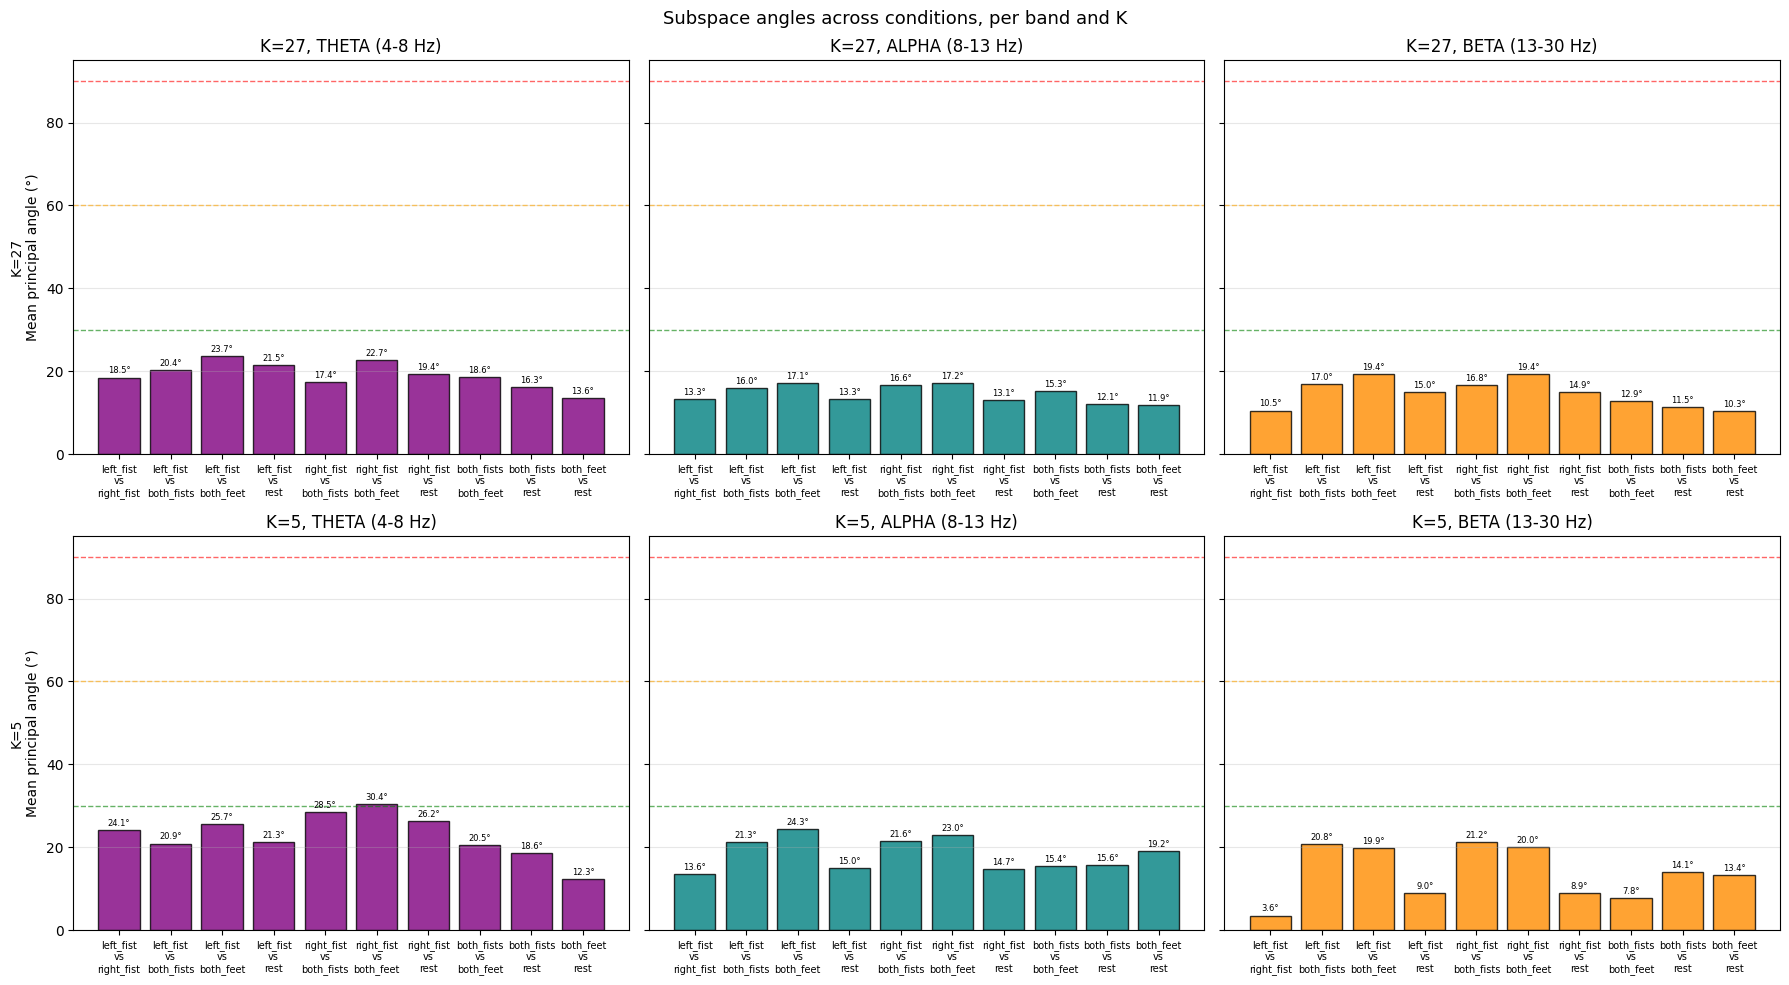

In [10]:
pair_labels = [f"{a}\nvs\n{b}" for a, b in combinations(CONDITIONS, 2)]
x = np.arange(len(pair_labels))
colors_per_band = {"theta": "purple", "alpha": "teal", "beta": "darkorange"}

fig, axes = plt.subplots(len(K_VALUES), len(BANDS),
                          figsize=(6*len(BANDS), 5*len(K_VALUES)),
                          sharey=True)

for row_idx, k in enumerate(K_VALUES):
    for col_idx, band_name in enumerate(BANDS):
        ax = axes[row_idx, col_idx]
        angles = [band_angles[k][band_name][(a, b)]
                  for a, b in combinations(CONDITIONS, 2)]
        ax.bar(x, angles, color=colors_per_band[band_name],
               alpha=0.8, edgecolor='black')
        ax.set_xticks(x)
        ax.set_xticklabels(pair_labels, fontsize=7)
        ax.set_title(f"K={k}, {band_name.upper()} ({BANDS[band_name][0]}-{BANDS[band_name][1]} Hz)")
        ax.axhline(30, color='green',  linestyle='--', linewidth=1, alpha=0.6)
        ax.axhline(60, color='orange', linestyle='--', linewidth=1, alpha=0.6)
        ax.axhline(90, color='red',    linestyle='--', linewidth=1, alpha=0.6)
        ax.grid(axis='y', alpha=0.3)
        for i, val in enumerate(angles):
            ax.text(i, val + 0.5, f"{val:.1f}°", ha='center', va='bottom', fontsize=6)
    axes[row_idx, 0].set_ylabel(f"K={k}\nMean principal angle (°)")
    axes[row_idx, 0].set_ylim(0, 95)

plt.suptitle("Subspace angles across conditions, per band and K", fontsize=13)
plt.tight_layout()
plt.show()